In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

Running multiple nodes at the same time instead of one after another

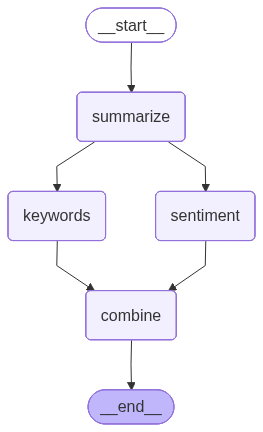

In [6]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

#  STATE 
class State(TypedDict):
    text: str
    summary: str
    sentiment: str
    keywords: str

# PARALLEL NODES 
def summarize(state):
    print("Running summarizer")
    return {"summary": f"Summary of {state['text']}"}

def sentiment(state):
    print("Running sentiment")
    return {"sentiment": "Positive"}

def keywords(state):
    print("Running keywords")
    return {"keywords": ["AI", "LangGraph"]}

# FINAL NODE

def combine(state):
    print("Combining results")
    return state

#  BUILD GRAPH

builder = StateGraph(State)

builder.add_node("summarize", summarize)
builder.add_node("sentiment", sentiment)
builder.add_node("keywords", keywords)
builder.add_node("combine", combine)

builder.set_entry_point("summarize")

# FAN-OUT (parallel execution from same input)
builder.add_edge("summarize", "sentiment")
builder.add_edge("summarize", "keywords")

#  FAN-IN (merge step)
builder.add_edge("sentiment", "combine")
builder.add_edge("keywords", "combine")

builder.add_edge("combine", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
result = graph.invoke({"text": "LangGraph is powerful"})
print(result)

Running summarizer
Running keywords
Running sentiment
Combining results
{'text': 'LangGraph is powerful', 'summary': 'Summary of LangGraph is powerful', 'sentiment': 'Positive', 'keywords': ['AI', 'LangGraph']}
